# Friends event segmentation code
**Contributors: James Antony**  

## Goals:
1. import data from event segmentation experiments, validate, and save as continuous and event-locked .npys

## Inputs
1. Event info (FriendsStoryboard.xlsx)
2. Segmentation scores ('(subnum)_friends.log)
 
## Outputs
1. event segmentation information

## Parts of this notebook:
1. import data
2. import event information
3. find match between event markers and event boundary agreement

In [20]:
vers=1 #event segmentation experiment version 1 or 2

#add packages
import math
import scipy
import matplotlib
import numpy as np 
import pandas as pd 
from scipy import stats
from scipy.stats import pearsonr
from matplotlib import cm
from datetime import datetime
import matplotlib.pyplot as plt
cfs=18 #defaults
plt.rcParams.update({'font.size': cfs})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
cm,cm2,fs0,fs1,fs2='gray','viridis',13,5,5 #colormap styles and fig sizes
figf="figs/"
print(pd.__version__)

#functions
def running_mean(x,N,shift): #smooth/shift segmentation data
    #x=1-D data of time course
    #N=# of seconds to smooth
    #shift=# seconds to shift backwards to align with the events
    rm=np.zeros((x.shape[0]))
    for i in range(0,len(x)):
        if i<N:
            rm[i]=np.mean(x[0]+x[i+N]*0.5) #rm[i]=np.mean(x[0:i+N])
        elif i>len(x)-1-N:
            rm[i]=np.mean(x[i-N]*0.5+x[len(x)-1]) #rm[i]=np.mean(x[i-N:len(x)-1])
        else:
            rm[i]=np.mean(x[i-N]*0.5+x[i]+x[i+N]*0.5) #rm[i]=np.mean(x[i-N:i+N])
    if shift>0: #shift in time
        rm2=np.zeros((x.shape[0]))
        rm2[:-shift]=rm[shift:]
        rm2[-shift:]=math.nan
        rm=rm2+0
    return rm

def findsecs(tstring): #find absolute # of seconds, based on HMS input
    date_time2 = datetime.strptime(tstring, "%H:%M:%S")
    a_timedelta = date_time2 - datetime(1900, 1, 1)
    seconds = a_timedelta.total_seconds()
    return seconds

def implot(v,dat,xl,yl,fs1,fs2): #standard imshow plot
    f, ax = plt.subplots(1,1, figsize = (fs1,fs2))
    im=ax.imshow(dat.T,interpolation='none',cmap=cm,aspect='auto')
    ax.set_xlabel(xl) 
    ax.set_ylabel(yl) 
    ax.set_yticks(np.arange(len(v)))
    ax.set_yticklabels(v)
    f.tight_layout()
    #fn=figf + yl + ".pdf"
    #plt.savefig(fn, transparent=True)
    
def histplot(lags,bins,xl,yl,fnx,tn):
    f, ax = plt.subplots(1,1,figsize = (fs1/2,fs2/2))
    ax.hist(lags,bins)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)        
    f.tight_layout()
    #fn=figf+"time_"+fnx+".pdf"
    #plt.savefig(fn, transparent=True)
    ax.set_title(tn)

1.3.5


## 1. import data

In [21]:
base='~/Desktop/friends_fmri/data/behavioral/' # dir - CHANGE if you run from a different device!
dn=base+'eventseg/' #+'data/' #base dir - CHANGE THIS to run on your machine!!
if vers==1:
    subs=['002','003','005','006','007','009','010','011','012','014','016','017','018','020',
         '023','026','027','028','029','030']
else:
    subs=['031','032','033','035','036','037','038','039','040','041','042','043','044','045',
         '046','047','049','050','051','052','053','054','055','056','057']
#vers 1 - exclusions
#'04': English not 1st language, unsure of task '08': English not 1st language, clicked extra
#'015','024',#no responses,
#'19': unsure of task, #'21': unsure clicked @ right time, 
#'22': threshold changed over time
#'25': confused, maybe clicked inaccurately

#vers 2
#'048': no responses
#'034': unsure of task

nS=len(subs)
print('# subjects:',nS)
mov_length=42*60-1 #movie length
event_xsub=np.zeros((nS,mov_length)) #pre-allocate matrix for subject responses
txt='Keypress: space' #goal text that we're looking for
colnames=['Time','Type','Notes'] #custom columns
for i in range(nS):
    fn=dn+subs[i]+'/'+subs[i]+'_friends.log' #filename
    df=pd.read_csv(fn, sep='\t',header=None,names=colnames) 
    
    temp = df[df['Notes'].str.contains('movie: movie = ')] 
    mov_start=temp.values[0][0] 
    temp = df[df['Notes'].str.contains(txt)]  #find all rows that have this text
    clicktimes=temp['Time'].values-mov_start  #find button press times
    clicktimes=clicktimes.astype(int)
    #print(subs[i])
    print(clicktimes)
    event_xsub[i,clicktimes]=1

# subjects: 25
[  10   18   33   67   85  126  148  158  179  244  265  292  305  331
  338  342  364  393  430  444  468  532  560  566  595  600  637  662
  695  701  710  725  738  767  787  799  814  824  834  845  874  908
  916  922  973  985  999 1031 1083 1100 1113 1221 1231 1247 1266 1275
 1333 1372 1441 1451 1512 1541 1579 1618 1653 1666 1755 1767 1775 1794
 1812 1826 1843 1883 1894 1910 1924 1928 1943 1958 1997 2007 2021 2061
 2100 2157 2192 2193 2204 2238 2259 2267 2284 2331 2452 2461 2488 2488
 2502]
[   8   38   69   86  156  175  178  244  292  307  341  364  433  469
  525  565  599  623  689  728  738  772  828  856  903  970  999 1030
 1082 1113 1204 1228 1262 1301 1373 1452 1503 1538 1589 1620 1648 1651
 1676 1724 1762 1809 1836 1959 1997 2008 2062 2094 2128 2204 2238 2273
 2283 2320 2460]
[ 465  492  917 1229]
[  21   37   67  120  123  150  177  190  242  247  291  304  339  341
  364  367  392  426  438  453  454  466  478  487  525  566  595  598
  620  665  691 

(2519,)


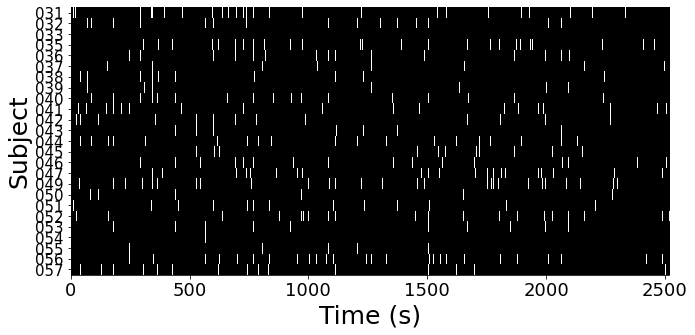

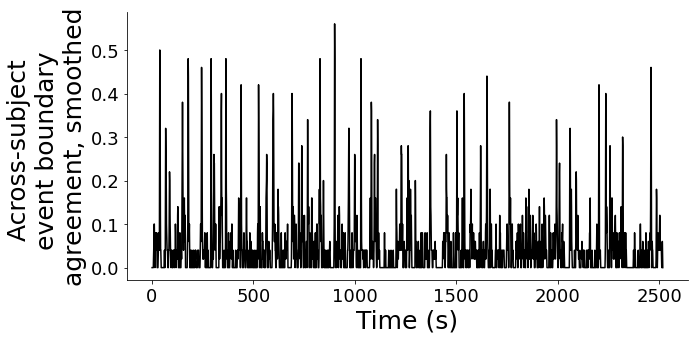

In [22]:
#plot data from all subjects
fsz,fs=10,25
f,ax=plt.subplots(nrows=1,ncols=1,figsize=(fsz,fsz/2))
im=ax.imshow(event_xsub,interpolation='none',aspect='auto',cmap='gray')
ax.set_ylabel('Subject',fontsize=fs)
ax.set_xlabel('Time (s)',fontsize=fs)
ax.set_yticks(np.linspace(0,nS-1,nS))
ax.set_yticklabels(subs,fontsize=fs*0.6)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
f.tight_layout()
#f.savefig(figf+'response_all_subs_'+str(vers)+'.pdf', transparent=True)

tc_m=np.mean(event_xsub,axis=0) #average time course x-subs
tc_m_s=running_mean(tc_m,1,0) #time course, w/ smoothing - main analysis
print(tc_m.shape)

f,ax=plt.subplots(nrows=1,ncols=1,figsize=(fsz,fsz/2))
plt.plot(tc_m_s,'k')
ax.set_ylabel('''Across-subject 
event boundary 
agreement, smoothed''',fontsize=fs)
ax.set_xlabel('Time (s)',fontsize=fs)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
f.tight_layout()
f.savefig(figf+'xsub_eb_agree_'+str(vers)+'.pdf', transparent=True)
f.savefig(figf+'response_xsubs_'+str(vers)+'.pdf', transparent=True)

# 2. import event information

In [23]:
#import event information from storyboard file
df = pd.read_excel(base+'friendsStoryBoard.xlsx','FriendsNarrComb') #read in
df['Secs']="" #pre-assign empty secs column
for i in range(df.shape[0]):
    if len(str(df['Time'][i]))>17:
        z=str(df['Time'][i])
        df['Secs'][i]=findsecs(z[11:])
    else:
        df['Secs'][i]=findsecs(str(df['Time'][i])) #old way
cols = df.columns.tolist()
cols = cols[-1:] + cols[:-1]
df = df[cols]
tsecs=int(df['Secs'][df.shape[0]-1]) #total seconds
e2s=np.where(np.diff(df['Episode']==1))[0]
e2s=e2s[0]+1
print(e2s)
df

30


/var/folders/tf/vdd5gkts7zz5byycgl6j2r0c0000gn/T/ipykernel_46198/3694698585.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Secs'][i]=findsecs(z[11:])


,Secs,Episode,EventModelNum,TimeOrig,Time,Character1,Character2,Character3,Character4,Character5,...,Place,Explanation,SceneNum,EventModel1,EMchangeWSTchange,Notes,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,0.0,1,1.0,1900-01-01 00:00:00,1900-01-01 00:00:00,Joey,Chandler,Ursula,NaN,NaN,...,Riffs restaurant,Joey and Chandler see a waitress and think it'...,1.0,Phoebe/Ursula/Joey,NaN,NaN,NaN,NaN,Event models,NaN
1,38.0,1,2.0,1900-01-01 00:01:25,1900-01-01 00:00:38,Ross,Monica,Rachel,Phoebe,NaN,...,Central Perk,"In the coffeeshop, Ross complains about monkey...",2.0,Marcel/SAP,1.0,NaN,NaN,NaN,Marcel/SAP,MSAP
2,66.0,1,3.0,1900-01-01 00:01:58,1900-01-01 00:01:06,Ross,Monica,Rachel,Phoebe,Joey,...,Central Perk,Joey and Chandler see Phoebe from outside the ...,2.0,Phoebe/Ursula/Joey,NaN,NaN,NaN,NaN,Phoebe/Ursula/Joey,JPU
3,147.0,1,4.0,1900-01-01 00:03:17,1900-01-01 00:02:27,Ross,Monica,Rachel,Phoebe,Joey,...,Central Perk,Ross mentions that he needs to leave for Lamaz...,2.0,Ross parenting,NaN,NaN,NaN,NaN,Ross parenting,RP
4,178.0,1,5.0,1900-01-01 00:03:50,1900-01-01 00:02:58,Ross,Carol,Susan,Coach,NaN,...,Lamaze class,"In Lamaze class, Ross, Carol, and Susan awkwar...",3.0,Ross parenting,0.0,"EM stay, scene change after edit",NaN,NaN,Chandler/Nina/boss,CNB
5,244.0,1,6.0,1900-01-01 00:05:01,1900-01-01 00:04:04,Chandler,Nina,NaN,NaN,NaN,...,Chandler's office,Chandler invites Nina into his office and they...,4.0,Chandler/Nina/boss,1.0,NaN,NaN,NaN,Rachel/Monica,Neighbor/lights/ankle/insurance/date/hospital2
6,291.0,1,7.0,1900-01-01 00:05:52,1900-01-01 00:04:51,Chandler,Rachel,Monica,Ross,Phoebe,...,Monica's apartment,"Chandler tells friends that Nina is very cute,...",5.0,Chandler/Nina/boss,0.0,"EM stay, scene change after edit",NaN,NaN,NaN,NaN
7,303.0,1,8.0,1900-01-01 00:06:08,1900-01-01 00:05:03,Chandler,Rachel,Monica,Ross,Phoebe,...,Monica's apartment,Marcel (Ross's monkey) steals the TV remote an...,5.0,Marcel/SAP,NaN,NaN,NaN,NaN,NaN,NaN
8,341.0,1,9.0,1900-01-01 00:06:45,1900-01-01 00:05:41,Chandler,Rachel,Monica,Ross,Phoebe,...,Monica's apartment,Rachel and Monica reveal that they still have ...,5.0,Rachel/Monica,NaN,NaN,NaN,NaN,NaN,NaN
9,363.0,1,10.0,1900-01-01 00:07:09,1900-01-01 00:06:03,Chandler,Rachel,Monica,Ross,Phoebe,...,Monica's apartment,Joey says he thinks Ursula likes him. Chandler...,5.0,Phoebe/Ursula/Joey,NaN,NaN,NaN,NaN,NaN,NaN


All changes: [  38   66  147  178  244  291  303  341  363  430  438  525  563  598
  620  689  694  736  766  828  900  969  998 1030 1081 1096 1112 1204
 1227 1261 1370 1450 1503 1538 1579 1650 1761 1766 1994 2007 2020 2059
 2091 2203 2236 2257 2281 2310 2319 2459 2485 2515]
All scene changes : [  38  178  244  291  438  525  563  598  689  828  900  969 1030 1081
 1204 1227 1261 1370 1503 1538 1650 1761 1994 2091 2203 2236 2281 2319
 2459]
sum edges: 52


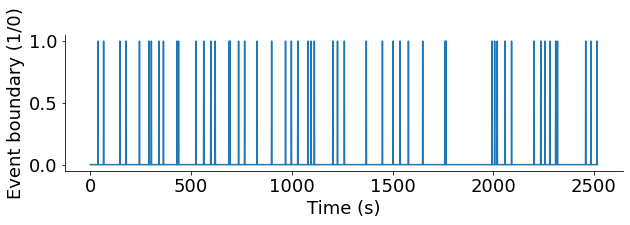

In [24]:
ts=int(np.floor(tsecs)) #total # seconds
#qq=df['Secs'][:-1] #find times of event changes #ignore first time point b/c not boundary!
qq=df['Secs'] #find times of event changes #ignore first time point b/c not boundary!
all_edges=qq[1:].to_numpy().astype(int) #vector of boundaries between events
#qqq=np.diff(df['SceneNum'][:-1]) #find spatiotemporal changes via 'diff' function
qqq=np.diff(df['SceneNum']) #find spatiotemporal changes via 'diff' function
ix=np.where(qqq==1) #where the spatiotemporal changes occur
all_edges_st=qq[ix[0]+1].to_numpy().astype(int) #vector of boundaries between spatiotemporal events
print('All changes: %s' %all_edges)
print('All scene changes : %s' %all_edges_st)

all_edges_tc,all_edges_st_tc=np.zeros((mov_length)),np.zeros((mov_length)) #pre-allocate
all_edges_tc[all_edges],all_edges_st_tc[all_edges_st]=1,1 #assign edges as ones
f, ax = plt.subplots(1,1,figsize = (fs1*2,fs2/2)) #for instance
ax.plot(all_edges_tc)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Event boundary (1/0)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
print('sum edges:',len(np.where(0<all_edges_tc)[0]))

Characters: ['Boss', 'Carol', 'Chandler', 'Coach', 'Doctor1', 'Doctor2', 'Joey', 'Marcel', 'Monica', 'Mr. Hickles', 'Nina', 'Phoebe', 'Rachel', 'Receptionist', 'Ross', 'RossFather', 'Susan', 'Ursula', 'Woman1', 'Woman2'], total #: 20
Event models: ['Chandler/Nina/boss', 'Marcel/SAP', 'Phoebe/Ursula/Joey', 'Rachel/Monica', 'Ross parenting'], total #: 5
Places: ['Central Perk', "Chandler's office", 'Hallway', 'Hospital lounge', 'Hospital room', 'Lamaze class', "Monica's apartment", 'Riffs restaurant', 'Rooftop', 'Some Restaurant'], total #: 10


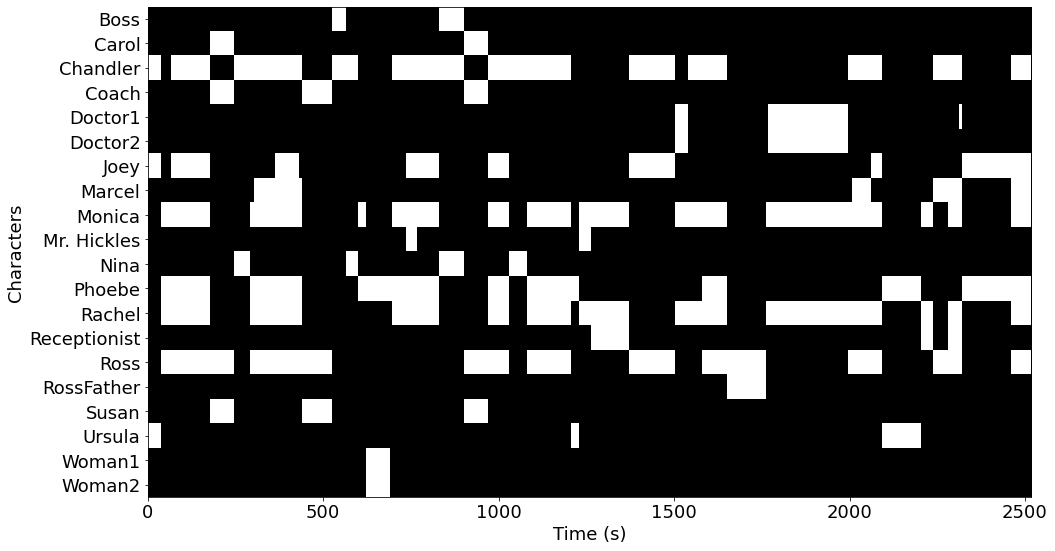

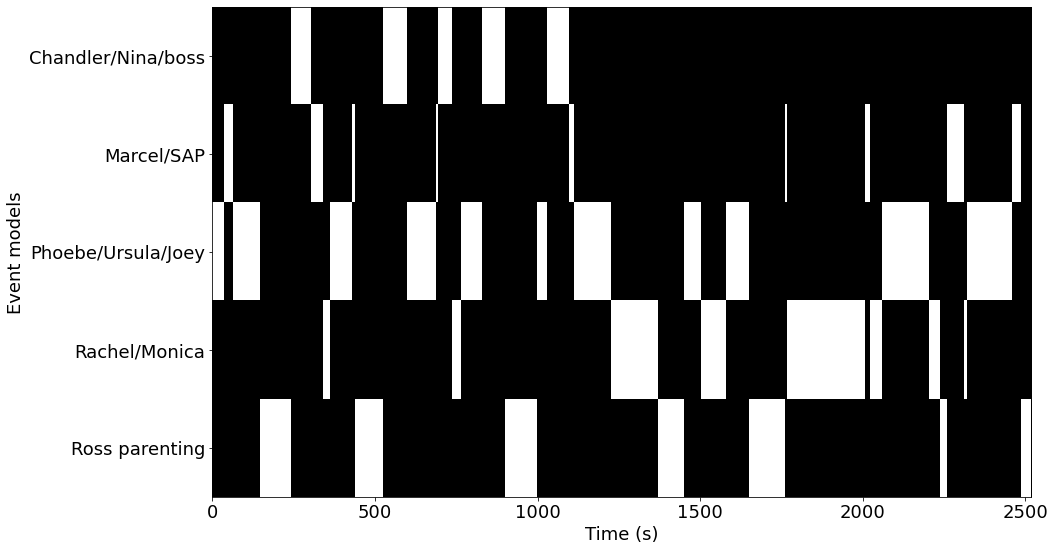

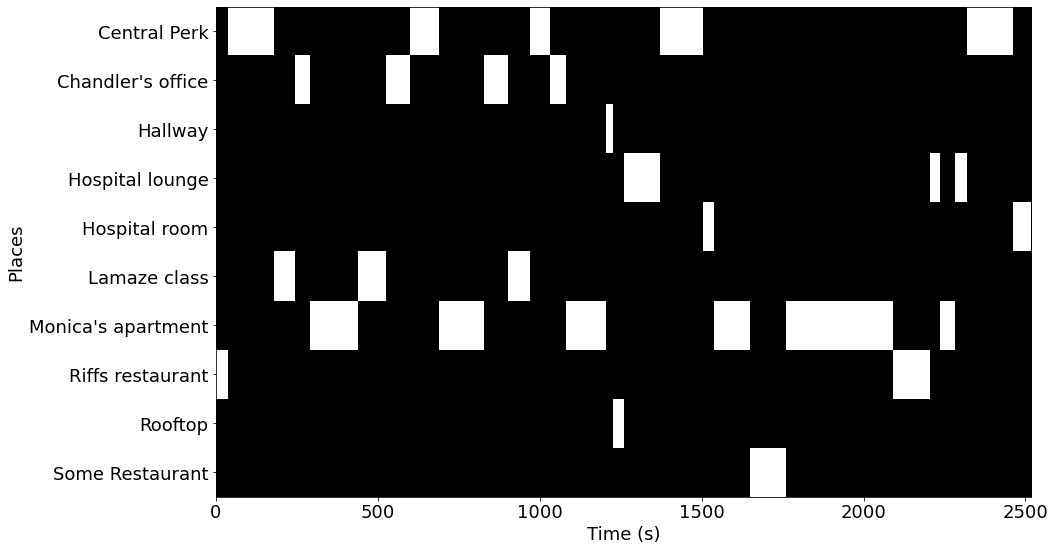

In [25]:
#collect all characters, event models, and places; plot timecourses
a,b,c=list(set(df['Character1'])),list(set(df['Character2'])),list(set(df['Character3']))
d,e,f=list(set(df['Character4'])),list(set(df['Character5'])),list(set(df['Character6']))
g=list(set(df['Character7']))
chars=set(a+b+c+d+e+f+g) #combine
chars = [x for x in chars if str(x) != 'nan']
chars.remove('[end credits 2]')
chars.sort()
print('Characters: %s, total #: %s' %(chars,len(chars)))
#event model list
a=list(set(df['EventModel1']))
ems=set(a)
ems = [x for x in ems if str(x) != 'nan']
ems.sort()
print('Event models: %s, total #: %s' %(ems,len(ems)))
#place list
places=list(set(df['Place']))
places = [x for x in places if str(x) != 'nan']
places.sort()
print('Places: %s, total #: %s' %(places,len(places)))

#cmat,emat,pmat=np.zeros((tsecs,len(chars))),np.zeros((tsecs,len(ems))),np.zeros((tsecs,len(places)))
cmat,emat,pmat=np.zeros((mov_length,len(chars))),np.zeros((mov_length,len(ems))),np.zeros((mov_length,len(places)))
for i in range(df.shape[0]-1): #up to last moment
    fsec=int(df['Secs'][i]) #first second in the event
    lsec=int(df['Secs'][i+1]) #last second in the event
    for ii,c in enumerate(chars):
        if df['Character1'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
        if df['Character2'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
        if df['Character3'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
        if df['Character4'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
        if df['Character5'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
        if df['Character6'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
        if df['Character7'][i]==chars[ii]:
            cmat[fsec:lsec,ii]=1
    for ii,l in enumerate(ems):
        if df['EventModel1'][i]==ems[ii]:
            emat[fsec:lsec,ii]=1
    for ii,l in enumerate(places):
        if df['Place'][i]==places[ii]:
            pmat[fsec:lsec,ii]=1

implot(chars,cmat,'Time (s)','Characters',15,8) #plot each attribute over time
implot(ems,emat,'Time (s)','Event models',15,8)
implot(places,pmat,'Time (s)','Places',15,8)

#find event order - do it this way b/c otherwise ST changes w/o EM changes are not read in!
e_o=np.zeros((df.shape[0]-1,2))
for i in range(df.shape[0]-1):
    currsec=int(df['Secs'][i])
    qq=np.where(emat[currsec,:]==1)[0] #f
    e_o[i,0],e_o[i,1]=currsec,qq

In [26]:
#plot different event markers!
n_edges=len(all_edges)
print('All changes: %s' %all_edges)
print('# changes: %s' %(n_edges))
print('All scene changes: %s' %all_edges_st)
print('# scene changes: %s' %(len(all_edges_st)))

#is there a change in characters?
#cmdmat_all,j=np.zeros((ts,cmat.shape[1])),0
cmdmat_all,j=np.zeros((mov_length,cmat.shape[1])),0
for i in range(cmat.shape[1]):
    cmdmat_all[1:,i]=np.diff(cmat[:,i])
all_edges_cmd=np.max(cmdmat_all,axis=1) #vector for change in characters 

#is there a change in the event model?
#emdmat_all=np.zeros((ts,emat.shape[1]))
emdmat_all=np.zeros((mov_length,emat.shape[1]))
j=0
for i in range(emat.shape[1]):
    emdmat_all[1:,i]=np.diff(emat[:,i])
all_edges_em=np.max(emdmat_all,axis=1)

#is there a change in the location (differs slightly from spatiotemporal, since sometimes jump in time w/o space)
#stdmat_all=np.zeros((ts,pmat.shape[1]))
stdmat_all=np.zeros((mov_length,pmat.shape[1]))
for i in range(pmat.shape[1]):
    stdmat_all[1:,i]=np.diff(pmat[:,i])#
all_edges_sp=np.max(stdmat_all,axis=1)

#is there a change ONLY in the event model and NOT in the location?
all_edges_emo=all_edges_em-all_edges_sp #event model change only
all_edges_emo[np.where(all_edges_emo<0)[0]]=0 #zero out negative stdmat

All changes: [  38   66  147  178  244  291  303  341  363  430  438  525  563  598
  620  689  694  736  766  828  900  969  998 1030 1081 1096 1112 1204
 1227 1261 1370 1450 1503 1538 1579 1650 1761 1766 1994 2007 2020 2059
 2091 2203 2236 2257 2281 2310 2319 2459 2485 2515]
# changes: 52
All scene changes: [  38  178  244  291  438  525  563  598  689  828  900  969 1030 1081
 1204 1227 1261 1370 1503 1538 1650 1761 1994 2091 2203 2236 2281 2319
 2459]
# scene changes: 29


# 3. find match between event markers and event boundary agreement

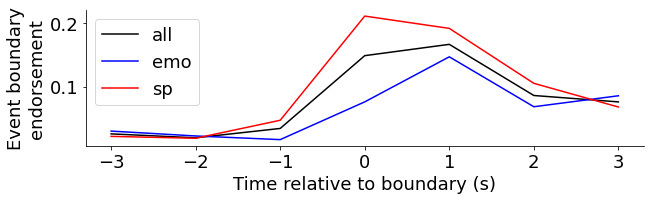

In [27]:
rge=3 #+/- this to see alignment around 0
xt=np.linspace(-rge,rge,rge*2+1)
qq=np.where(all_edges_tc==1)[0]
rel_tc=np.zeros((rge*2+1,len(qq)))
for i in range(len(qq)):
    rel_tc[:,i]=tc_m[qq[i]-rge:qq[i]+rge+1]
        
qq=np.where(all_edges_emo==1)[0]
rel_emo=np.zeros((rge*2+1,len(qq)))
for i in range(len(qq)):
    rel_emo[:,i]=tc_m[qq[i]-rge:qq[i]+rge+1]
qq=np.where(all_edges_sp==1)[0]
rel_sp=np.zeros((rge*2+1,len(qq)))
for i in range(len(qq)):
    rel_sp[:,i]=tc_m[qq[i]-rge:qq[i]+rge+1]

f, ax = plt.subplots(1,1,figsize = (fs1*2,fs2/2)) 
ax.plot(xt,np.mean(rel_tc,1),'k')
ax.set_xlabel('Time relative to boundary (s)')
ax.set_ylabel('''Event boundary
endorsement''')
ax.plot(xt,np.mean(rel_emo,1),'b')
ax.plot(xt,np.mean(rel_sp,1),'r')
ax.legend(['all','emo','sp'],loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)        

In [28]:
#convolve or use running mean to smooth time courses
def convv(a,v):
    dat=np.convolve(a,v, 'same')
    return dat

use_conv=0
if use_conv:
    all_edges_tc_s=convv(all_edges_tc,np.mean(rel_tc,1))
    all_edges_emo_s=convv(all_edges_emo,np.mean(rel_emo,1))
    all_edges_sp_s=convv(all_edges_sp,np.mean(rel_sp,1))
    f, ax = plt.subplots(1,1,figsize = (fs1*2,fs2/2)) 
    pts=200
    ax.plot(all_edges_tc_s[:pts],'k')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Convolved time course')
    ax.plot(all_edges_emo_s[:pts],'b')
    ax.plot(all_edges_sp_s[:pts],'r')
    ax.legend(['all','emo','sp'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
else: #use running mean
    all_edges_tc_s=running_mean(all_edges_tc,1,0) #smooth but don't shift the event boundary timecourses
    all_edges_emo_s=running_mean(all_edges_emo,1,0) 
    all_edges_sp_s=running_mean(all_edges_sp,1,0) 

In [29]:
#run correlations between event boundary metrics and x-sub agreement!
qq=np.where(np.logical_and(~np.isnan(tc_m_s),~np.isnan(all_edges_tc_s)))[0]
x,y=all_edges_tc_s[qq],tc_m_s[qq]
corr=pearsonr(x,y)
print('all event model changes, r-squared = %.3f, p = %.3f' %(corr[0]**2,corr[1]))
x=all_edges_emo_s[qq]
corr=pearsonr(x,y)
print('all event model (ONLY) changes, r-squared = %.3f, p = %.3f' %(corr[0]**2,corr[1]))
x=all_edges_sp_s[qq]
corr=pearsonr(x,y)
print('all spatiotemporal changes, r-squared = %.3f, p = %.3f' %(corr[0]**2,corr[1]))

all event model changes, r-squared = 0.317, p = 0.000
all event model (ONLY) changes, r-squared = 0.041, p = 0.000
all spatiotemporal changes, r-squared = 0.307, p = 0.000


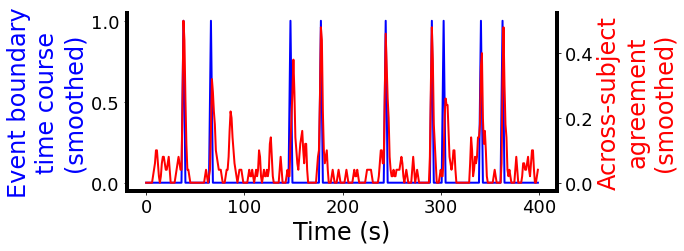

In [30]:
#plot alignment between x-sub agreement and overall event model changes - short segment of data
fpt,lpt,lw0,fos=0,400,2,24
f, ax = plt.subplots(1,1,figsize = (fs1*2,fs2*3/4)) 
ax.plot(all_edges_tc_s[fpt:lpt],'b',linewidth=lw0)
ax.set_xlabel('Time (s)',fontsize=fos,color='black')
ax.set_ylabel('''Event boundary
time course
(smoothed)''',fontsize=fos)
ax.tick_params(axis='both', labelcolor='black')
ax.yaxis.label.set_color('blue')
ax2=ax.twinx()
ax2.plot(tc_m_s[fpt:lpt],'r',linewidth=lw0)
ax2.set_ylabel('''Across-subject
agreement
(smoothed)''',fontsize=fos)
ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='both', labelcolor='black')
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
lw=4
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(lw)
ax2.spines['right'].set_linewidth(lw)

f.tight_layout()
fn=figf + "evseg_alignment-"+str(vers)+".pdf"
plt.savefig(fn, transparent=True)

In [31]:
# look @ individual subjects & see variation - how much DO they endorse each type of shift?
def fishr2z(x,y):
    rs=np.corrcoef(x,y)
    rs=rs[0,1]
    rs=np.multiply((np.log(1+rs)-np.log(1-rs)),0.5)
    return rs

corr_a,corr_emo,corr_st=np.zeros((nS)),np.zeros((nS)),np.zeros((nS))
for i in range(nS):
    tc_i=running_mean(event_xsub[i,:],1,1) #time course, smoothing amount
    qq=np.where(~np.isnan(tc_i))[0]
    x,y=all_edges_tc_s[qq],tc_i[qq]
    corr_a[i]=fishr2z(x,y)
    x=all_edges_emo_s[qq]
    corr_emo[i]=fishr2z(x,y)
    x=all_edges_sp_s[qq]
    corr_st[i]=fishr2z(x,y)

0.1591393461789958
Ttest_1sampResult(statistic=4.657492516842941, pvalue=9.9211680538086e-05)


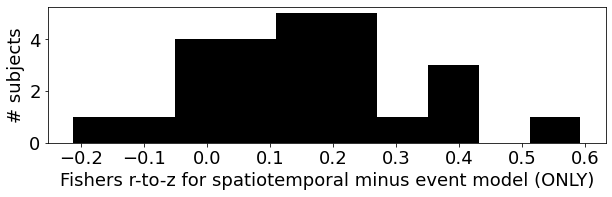

In [32]:
#difference in strength to ST vs. SO boundaries
f, ax = plt.subplots(1,1,figsize = (fs1*2,fs2/2)) 
diff=corr_st-corr_emo
ax.hist(diff,color='k')
ax.set_xlabel('Fisher''s r-to-z for spatiotemporal minus event model (ONLY)')
ax.set_ylabel('# subjects')
print(np.mean(diff))
p=stats.ttest_1samp(diff,popmean=0)
print(p)

In [33]:
e_a=np.zeros((len(all_edges_tc),2))
for i in range(e_o.shape[0]):
    fir=e_o[i,0]
    if i<e_o.shape[0]-1:
        las=e_o[i+1,0]
    else:
        las=len(all_edges_tc)
    v=np.linspace(int(fir),int(las)-1,int(las-fir))
    e_a[int(fir):int(las),0]=v
    e_a[int(fir):int(las),1]=e_o[i,1]

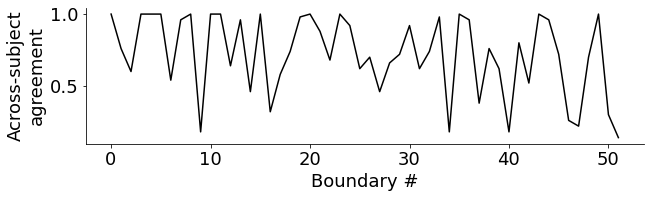

In [34]:
#compute event boundary agreement for each exp-defined boundary - use for event analyses later!!
interv=[0,2] #inclusive of 2!
ev_bound=np.zeros((n_edges))
for i in range(n_edges): #all seconds
    fir=all_edges[i]
    las=all_edges[i]+interv[1]+1
    ev_bound[i]=np.sum(tc_m_s[fir:las])
    if ev_bound[i]>1: 
        ev_bound[i]=1 #cap at 1 in case they press multiple
f, ax = plt.subplots(1,1,figsize = (fs1*2,fs2/2)) 
ax.plot(ev_bound,color='k')
ax.set_xlabel('Boundary #')
ax.set_ylabel('''Across-subject
agreement''')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)  

In [35]:
#put into TR space 
ntrs=1+len(tc_m)//2
tc_m_tr=np.zeros((ntrs))
for i in range(ntrs):
    if i<ntrs-2:
        tc_m_tr[i]=np.mean(tc_m[i*2:i*2+2])
    else:
        tc_m_tr[i]=np.mean(tc_m[i*2:])
print(tc_m_tr[:10])
print(tc_m[:20])
tc_m_tr=np.hstack((tc_m_tr,np.zeros((3))))
print(tc_m_tr.shape)

[0.   0.   0.   0.   0.02 0.06 0.02 0.   0.04 0.04]
[0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.   0.08 0.04 0.04 0.
 0.   0.   0.04 0.04 0.04 0.04]
(1263,)


In [36]:
#save variables
fn='pydata/eventseg'+str(vers)+'.npy'
np.save(fn,event_xsub) 
fn='pydata/eventseg'+str(vers)+'_tc_i.npy'
np.save(fn,tc_i)
fn='pydata/tc_m_s'+str(vers)+'.npy'
np.save(fn,tc_m_s) 
fn='pydata/tc_m_tr'+str(vers)+'.npy'
np.save(fn,tc_m_tr) 
fn='pydata/eventseg'+str(vers)+'_st_emo_diff.npy'
np.save(fn,diff) 
fn='pydata/eventseg'+str(vers)+'_corr_a.npy'
np.save(fn,corr_a) 
fn='pydata/eventseg'+str(vers)+'_corr_st.npy'
np.save(fn,corr_st) 
fn='pydata/eventseg'+str(vers)+'_corr_emo.npy'
np.save(fn,corr_emo) 
fn='pydata/ev_bound'+str(vers)+'.npy'
np.save(fn,ev_bound) 
fn='pydata/e_a.npy'
np.save(fn,e_a) 
fn='pydata/all_edges_tc.npy'
np.save(fn,all_edges_tc) 
fn='pydata/all_edges_emo.npy'
np.save(fn,all_edges_emo) 
fn='pydata/all_edges_sp.npy'
np.save(fn,all_edges_sp)
fn='pydata/all_edges_tc_s.npy'
np.save(fn,all_edges_tc_s) 
fn='pydata/all_edges_emo_s.npy'
np.save(fn,all_edges_emo_s) 
fn='pydata/all_edges_sp_s.npy'
np.save(fn,all_edges_sp_s)

# Validate versions w/ each other -- run after running both

In [37]:
def astats(d1,d2,note):
    m1,m2=np.mean(d1),np.mean(d2)
    n1,n2=len(d1),len(d2)
    df=n1+n2-2
    s1,s2=np.std(d1)/np.sqrt(n1),np.std(d2)/np.sqrt(n2)
    tt=stats.ttest_ind(d1,d2)
    pools=np.sqrt(((n1-1)*np.nanvar(d1)+(n2-1)*np.nanvar(d2))/df)
    d=(np.mean(d1)-np.nanmean(d2))/pools#Cohen's d
    b=np.zeros((1)) #pre-assign one blank row
    r=pd.DataFrame()
    r['m1'],r['m2'],r['n1'],r['n2'],r['s1'],r['s2'],r['eff_sz'],r['t'],r['p']=b,b,b,b,b,b,b,b,b
    r['m1'],r['m2'],r['n1'],r['n2'],r['s1'],r['s2'],r['eff_sz'],r['t'],r['p']=m1,m2,n1,n2,s1,s2,d,tt[0],tt[1]
    print(note)
    print(r)
    return r

#correlate 2 versions w/ each other
compv=1
if compv:
    #compare correlations in both versions - must run both versions first
    tc_m_s1=np.load('pydata/tc_m_s1.npy') #fisher r-to-z correlation for each subject
    tc_m_s2=np.load('pydata/tc_m_s2.npy')
    x,y=tc_m_s1,tc_m_s2
    corr=pearsonr(x,y)
    print('all event model changes, r-squared = %.3f, p = %.3f' %(corr[0]**2,corr[1]))

    #compare correlations in both versions - must run both versions first
    corr_a1=np.load('pydata/eventseg1_corr_a.npy') #fisher r-to-z correlation for each subject
    corr_a2=np.load('pydata/eventseg2_corr_a.npy')
    p=astats(corr_a1,corr_a2,'corr_a')
    diff1=np.load('pydata/eventseg1_st_emo_diff.npy') 
    diff2=np.load('pydata/eventseg2_st_emo_diff.npy')
    p=astats(diff1,diff2,'diffs')
    corr_emo1=np.load('pydata/eventseg1_corr_emo.npy') 
    corr_emo2=np.load('pydata/eventseg2_corr_emo.npy')
    p=astats(corr_emo1,corr_emo2,'corr_EMO')
    corr_st1=np.load('pydata/eventseg1_corr_st.npy') 
    corr_st2=np.load('pydata/eventseg2_corr_st.npy')
    p=astats(corr_st1,corr_st2,'corr_ST')

all event model changes, r-squared = 0.475, p = 0.000
corr_a
         m1      m2  n1  n2        s1        s2    eff_sz         t         p
0  0.334481  0.2898  20  25  0.030955  0.029224  0.312943  1.019839  0.313509
diffs
         m1        m2  n1  n2        s1        s2    eff_sz         t  \
0  0.412298  0.159139  20  25  0.050688  0.033478  1.292832  4.209273   

          p  
0  0.000128  
corr_EMO
         m1        m2  n1  n2        s1        s2    eff_sz        t         p
0  0.017504  0.114794  20  25  0.012461  0.016351 -1.361957 -4.44185  0.000061
corr_ST
         m1        m2  n1  n2        s1        s2    eff_sz         t  \
0  0.429802  0.273934  20  25  0.046372  0.031806  0.856489  2.788873   

          p  
0  0.007849  


In [38]:
#import bayesian surprise measures - not using
run_b_sur=0
if run_b_sur:
    fn='b_sur.npy'
    b_sur=np.load(fn) #load surprise
    qq=np.where(b_sur>-1)[0] #grab relevant values

    #correlate with across-subject agreement
    sz,lw=125,4
    f,ax=plt.subplots(nrows=1,ncols=1,figsize=(fsz,fsz/2))
    x,y,xl,yl=b_sur[qq],tc_m_s[qq],'Bayesian surprise','Across-subject agreement'
    print(x.shape)
    print(y.shape)
    ax.scatter(x,y,c='gray',marker='d',s=sz*0.1) #plot data points
    a,b=np.polyfit(x,y,1) #create best fit line
    plt.plot(x, a*x+b,'k',linewidth=lw)
    ax.set_xlabel(xl,fontsize=fs)
    ax.set_ylabel(yl,fontsize=fs)
    corr=np.corrcoef(x,y) #run pearson correlation
    print('r-squared = %s' %(corr[0,1]**2))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(lw)